In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

✅ Libraries loaded successfully!


In [10]:
df = pd.read_csv('/Users/marwan/skin-cancer-detection/data/raw/archive/HAM10000_metadata.csv')  

print(df.shape)
df.head()


(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [11]:
# General dataset info
print("=" * 40)
print("Dataset Information:")
print("=" * 40)
print(f"Number of images: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Information:
Number of images: 10015
Number of columns: 7

Data types:
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Class Distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Percentage:
dx
nv       66.9
mel      11.1
bkl      11.0
bcc       5.1
akiec     3.3
vasc      1.4
df        1.1
Name: proportion, dtype: float64


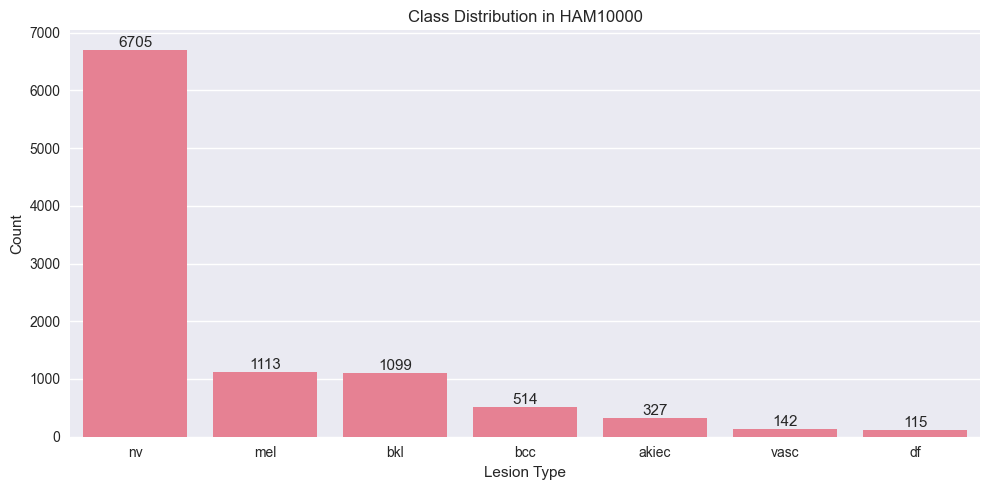

In [20]:
# Class distribution
print("Class Distribution:")
print("=" * 40)
print(df['dx'].value_counts())
print("\nPercentage:")
print(df['dx'].value_counts(normalize=True).round(3) * 100)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='dx', 
                   order=df['dx'].value_counts().index)
plt.title('Class Distribution in HAM10000')
plt.xlabel('Lesion Type')
plt.ylabel('Count')

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

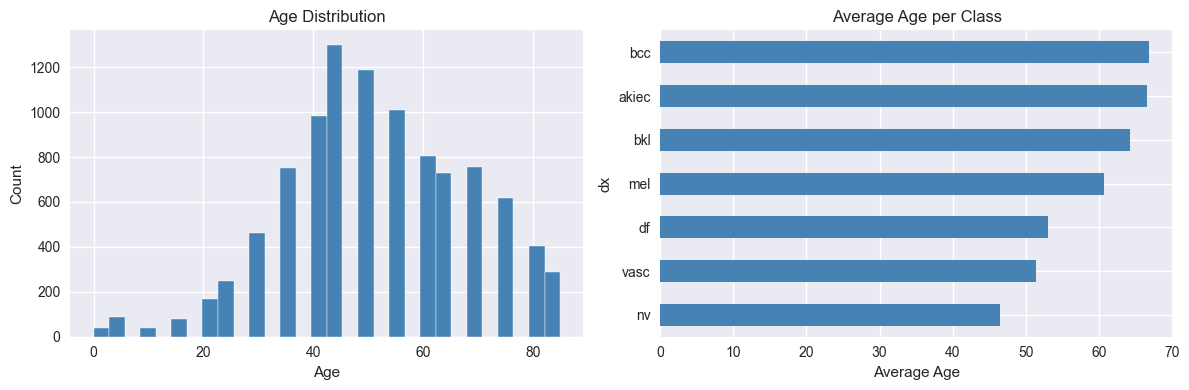


Age Statistics:
count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


In [27]:
# Age distribution
plt.figure(figsize=(12, 4))

# Plot 1 - Age distribution
plt.subplot(1, 2, 1)
df['age'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Plot 2 - Age per class
plt.subplot(1, 2, 2)
df.groupby('dx')['age'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Age per Class')
plt.xlabel('Average Age')

plt.tight_layout()
plt.show()

print("\nAge Statistics:")
print(df['age'].describe())

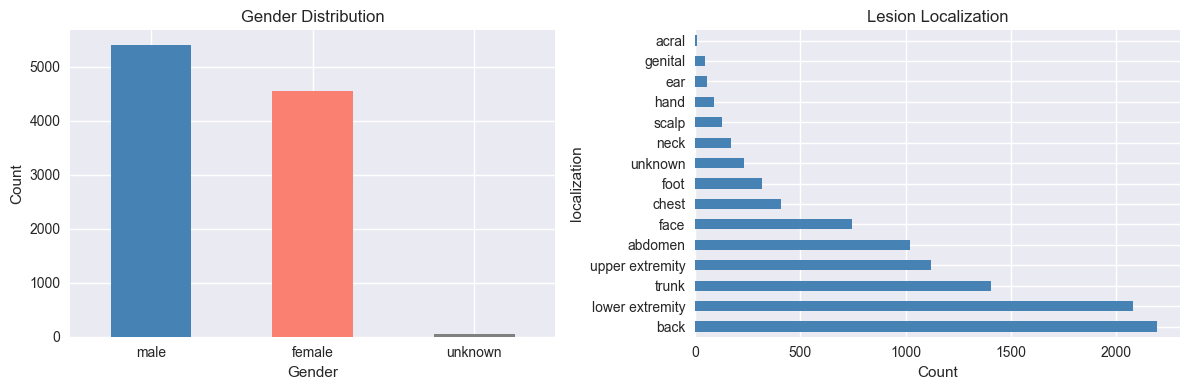


Gender counts:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

Top 5 locations:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64


In [28]:
plt.figure(figsize=(12, 4))

# Plot 1 - Gender distribution
plt.subplot(1, 2, 1)
df['sex'].value_counts().plot(kind='bar', color=['steelblue', 'salmon', 'gray'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Plot 2 - Localization distribution
plt.subplot(1, 2, 2)
df['localization'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Lesion Localization')
plt.xlabel('Count')

plt.tight_layout()
plt.show()

print("\nGender counts:")
print(df['sex'].value_counts())
print("\nTop 5 locations:")
print(df['localization'].value_counts().head())

Total images found: 10015


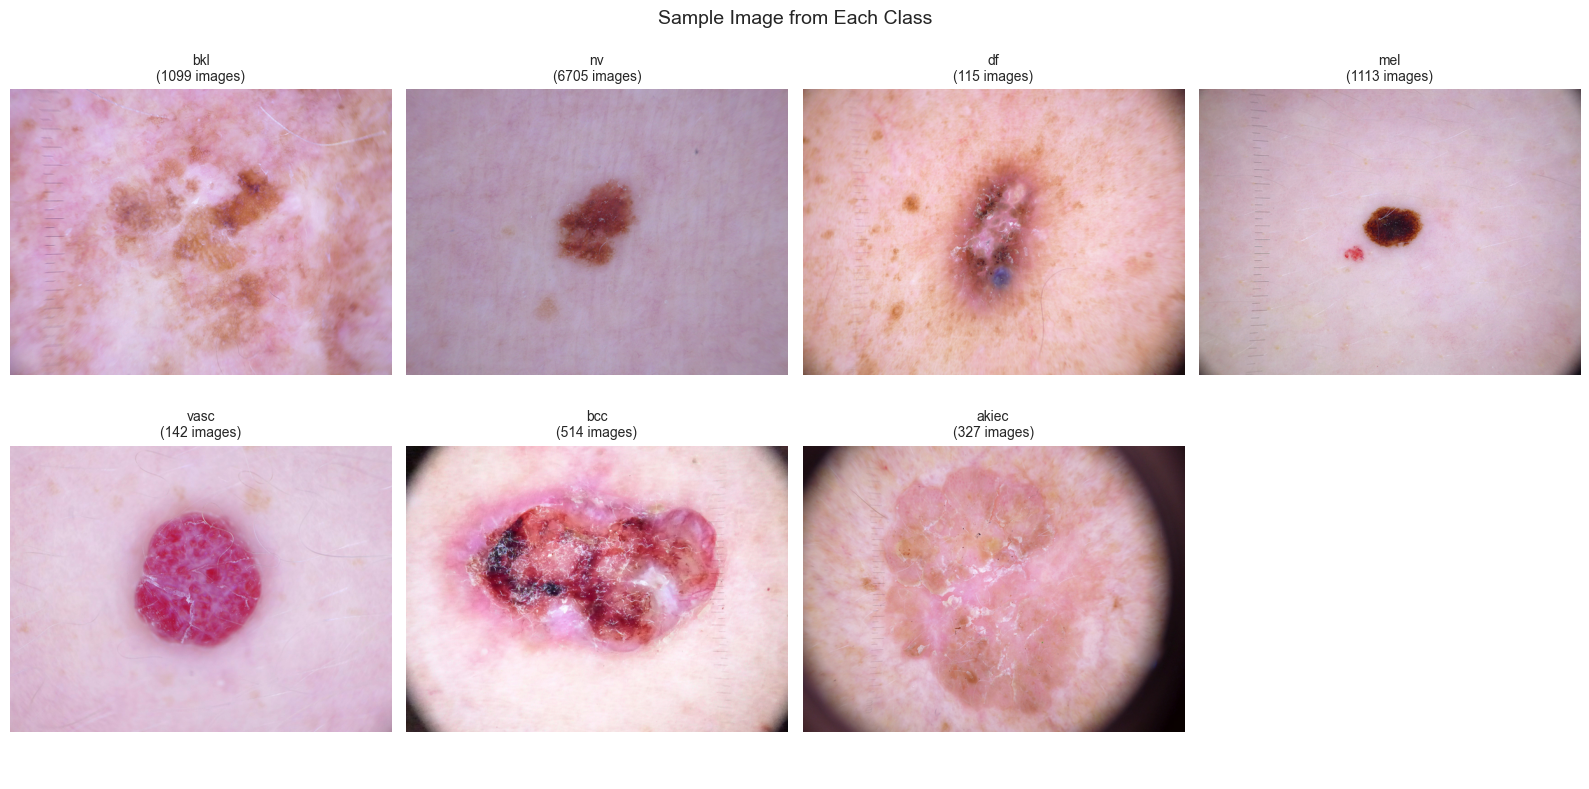

In [30]:
import os
from PIL import Image

# Path to images folders
img_dir1 = '/Users/marwan/skin-cancer-detection/data/raw/archive/HAM10000_images_part_1'
img_dir2 = '/Users/marwan/skin-cancer-detection/data/raw/archive/HAM10000_images_part_2'

# Build a dictionary: image_id -> full path
image_paths = {}
for img_name in os.listdir(img_dir1):
    image_id = img_name.replace('.jpg', '')
    image_paths[image_id] = os.path.join(img_dir1, img_name)
for img_name in os.listdir(img_dir2):
    image_id = img_name.replace('.jpg', '')
    image_paths[image_id] = os.path.join(img_dir2, img_name)

print(f"Total images found: {len(image_paths)}")

# Show one sample image from each class
classes = df['dx'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = df[df['dx'] == cls].iloc[0]
    img_path = image_paths.get(sample['image_id'])
    
    if img_path:
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f'{cls}\n({df[df["dx"]==cls].shape[0]} images)', 
                         fontsize=10)
        axes[i].axis('off')

axes[-1].axis('off')
plt.suptitle('Sample Image from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# Check image sizes
sample_images = list(image_paths.values())[:5]

print("Sample image sizes:")
for path in sample_images:
    img = Image.open(path)
    print(f"  {os.path.basename(path)}: {img.size} - Mode: {img.mode}")

Sample image sizes:
  ISIC_0026784.jpg: (600, 450) - Mode: RGB
  ISIC_0028971.jpg: (600, 450) - Mode: RGB
  ISIC_0026948.jpg: (600, 450) - Mode: RGB
  ISIC_0026790.jpg: (600, 450) - Mode: RGB
  ISIC_0028965.jpg: (600, 450) - Mode: RGB


In [32]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)

print(f"\n Dataset:")
print(f"  Total images       : {df.shape[0]}")
print(f"  Total columns      : {df.shape[1]}")
print(f"  Image size         : 600 x 450 RGB")

print(f"\n Class Imbalance (CRITICAL):")
for cls, count in df['dx'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    print(f"  {cls:6} : {count:4} ({pct:4.1f}%) {bar}")

print(f"\n Missing Values:")
print(f"  Age     : 57 missing → fill with median")
print(f"  Sex     : 57 unknown → fill with 'unknown'")

print(f"\n Age:")
print(f"  Range   : {df['age'].min()} - {df['age'].max()} years")
print(f"  Mean    : {df['age'].mean():.1f} years")
print(f"  Suspicious: min age = 0.0 → likely data error")

print(f"\n Top Locations:")
for loc, count in df['localization'].value_counts().head(3).items():
    print(f"  {loc:20} : {count}")

print(f"\n Decisions for Phase 2:")
print(f"  1. Resize images   : 600x450 → 224x224")
print(f"  2. Fix imbalance   : Weighted Loss + Augmentation")
print(f"  3. Fill missing    : Age median, Sex 'unknown'")
print(f"  4. Stratified split: Keep class ratio in train/val/test")
print("=" * 50)

EDA SUMMARY

 Dataset:
  Total images       : 10015
  Total columns      : 7
  Image size         : 600 x 450 RGB

 Class Imbalance (CRITICAL):
  nv     : 6705 (66.9%) ██████████████████████████████████████████████████████████████████
  mel    : 1113 (11.1%) ███████████
  bkl    : 1099 (11.0%) ██████████
  bcc    :  514 ( 5.1%) █████
  akiec  :  327 ( 3.3%) ███
  vasc   :  142 ( 1.4%) █
  df     :  115 ( 1.1%) █

 Missing Values:
  Age     : 57 missing → fill with median
  Sex     : 57 unknown → fill with 'unknown'

 Age:
  Range   : 0.0 - 85.0 years
  Mean    : 51.9 years
  Suspicious: min age = 0.0 → likely data error

 Top Locations:
  back                 : 2192
  lower extremity      : 2077
  trunk                : 1404

 Decisions for Phase 2:
  1. Resize images   : 600x450 → 224x224
  2. Fix imbalance   : Weighted Loss + Augmentation
  3. Fill missing    : Age median, Sex 'unknown'
  4. Stratified split: Keep class ratio in train/val/test
